# Customer Decision Hierarchy Gallery

The customer decision hierarchy renders a dendrogram of product substitutability, derived from co-purchase patterns. Products that share customer bases cluster on the same branch: those are the SKUs customers treat as interchangeable variations of the same need. Products on separate branches fill genuinely different needs.

Customer decision hierarchies excel at:
- **Range rationalization**: identify SKUs within the same cluster that are safe candidates for delisting
- **Private label strategy**: position PL alongside national brands customers already treat as variations of the same need
- **New product cannibalization**: predict which existing SKUs a new launch will draw volume from
- **Space productivity**: allocate facings based on whether a product fills a unique need or duplicates one

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from openretailscience.analysis.customer_decision_hierarchy import CustomerDecisionHierarchy

In [ ]:
# Hand-crafted yogurt assortment dataset, built vectorized and reproducible via a fixed seed.
# Three product lines - Greek, Regular, Kids - of three SKUs each. Shoppers mostly buy within
# their own line (skipping one SKU ~40% of the time), and the adult lines (Greek, Regular)
# cross-shop EACH OTHER far more than either reaches for Kids. That graded cross-shopping
# spreads the dendrogram out: the two adult lines merge first and the distinct Kids line joins
# last, rather than three branches collapsing onto distance 0.
#
# Each customer buys their SKUs in separate transactions, so `exclude_same_transaction_products`
# (the default) leaves every pair intact.

rng = np.random.default_rng(7)

PRODUCTS = [
    "Greek Vanilla",
    "Greek Strawberry",
    "Greek Honey",
    "Regular Vanilla",
    "Regular Strawberry",
    "Regular Peach",
    "Kids Squeeze Pouch",
    "Kids Yogurt Tube",
    "Kids Mini Cup",
]
GREEK, REGULAR, KIDS = 0, 1, 2
product_line = np.repeat([GREEK, REGULAR, KIDS], 3)  # line index of each of the nine SKUs

CUSTOMERS_PER_LINE = 25
BUYS_FULL_LINE = 0.6  # otherwise the shopper skips one of their line's three SKUs
CROSS_ADULT = 0.34  # per-SKU chance an adult shopper also buys the other adult line
CROSS_KIDS = 0.12  # per-SKU chance of crossing between an adult line and Kids

# Per-SKU cross-shop probability indexed by [shopper's line, product's line]. The diagonal is
# zero: own-line purchases are handled by the all-or-skip-one rule below, not by this matrix.
cross_prob_by_line = np.array(
    [
        [0.0, CROSS_ADULT, CROSS_KIDS],
        [CROSS_ADULT, 0.0, CROSS_KIDS],
        [CROSS_KIDS, CROSS_KIDS, 0.0],
    ]
)

n_customers = CUSTOMERS_PER_LINE * 3
home_line = np.repeat([GREEK, REGULAR, KIDS], CUSTOMERS_PER_LINE)

# Own line: buy all three SKUs, except the ~40% of shoppers who skip one (chosen uniformly).
bought = product_line[None, :] == home_line[:, None]
skips_one = rng.random(n_customers) >= BUYS_FULL_LINE
skipped_sku = home_line * 3 + rng.integers(0, 3, n_customers)
bought[skips_one, skipped_sku[skips_one]] = False

# Cross lines: each off-line SKU is bought independently at its line-pair rate.
bought |= rng.random((n_customers, len(PRODUCTS))) < cross_prob_by_line[home_line][:, product_line]

# Long form: one row per (customer, purchased SKU), each in its own transaction.
customer_idx, product_idx = np.nonzero(bought)
yogurt_transactions = pd.DataFrame(
    {
        "customer_id": 1_000 + customer_idx,
        "transaction_id": 5_000 + np.arange(customer_idx.size),
        "product_name": np.asarray(PRODUCTS)[product_idx],
    }
)

## Default Vertical Dendrogram

The simplest call: build the analysis from a transactions DataFrame and call `plot()`. The default `orientation="top"` grows the tree downward with leaves along the bottom. Branch height encodes substitution distance: tightly co-purchased SKUs join close to the bottom (they're substitutes), while branches that join near the top fill genuinely different needs.

---

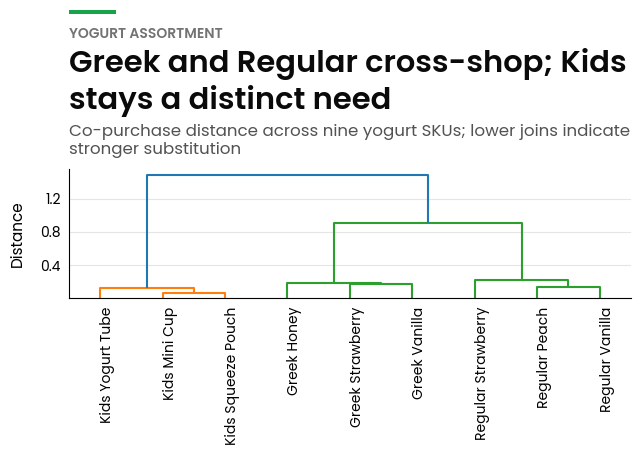

In [ ]:
cdh = CustomerDecisionHierarchy(yogurt_transactions, product_col="product_name")

cdh.plot(
    eyebrow="Yogurt assortment",
    title="Greek and Regular cross-shop; Kids stays a distinct need",
    subtitle="Co-purchase distance across nine yogurt SKUs; lower joins indicate stronger substitution",
)
plt.show()

## Horizontal Orientation

Pass `orientation="right"` for a horizontal layout. Leaves sit on the left, distance grows rightward. This is the most readable shape when product names are long, since labels never need to be rotated. The function passes the `orientation` keyword straight through to scipy's `dendrogram`; `"left"`, `"top"`, and `"bottom"` work the same way.

---

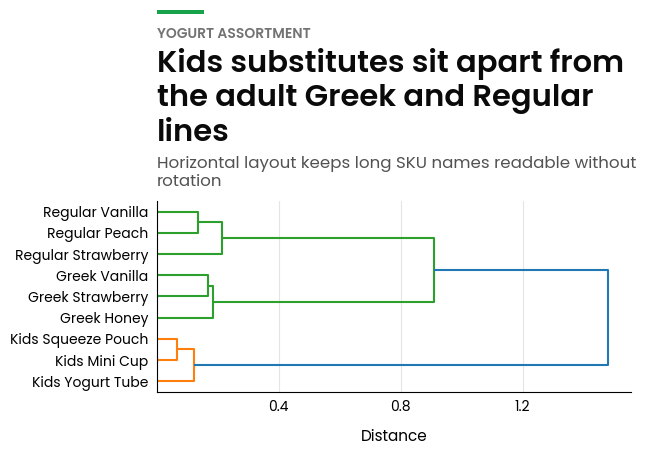

In [ ]:
cdh.plot(
    orientation="right",
    eyebrow="Yogurt assortment",
    title="Kids substitutes sit apart from the adult Greek and Regular lines",
    subtitle="Horizontal layout keeps long SKU names readable without rotation",
)
plt.show()

## Adding a Source Annotation

Pass `source_text` to drop a small attribution line at the bottom of the chart. Useful when the image will be exported into a deck or report and the audience needs to know which dataset produced it. Combine with the `eyebrow`, `title`, and `subtitle` block to ship a chart that reads as a finished artefact rather than an exploratory plot.

---

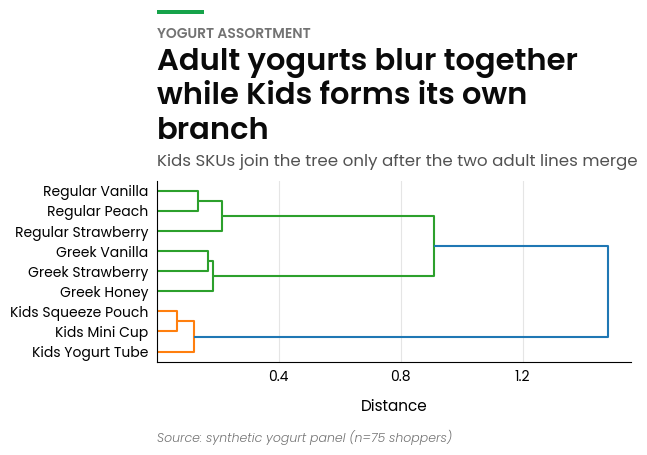

In [ ]:
cdh.plot(
    orientation="right",
    eyebrow="Yogurt assortment",
    title="Adult yogurts blur together while Kids forms its own branch",
    subtitle="Kids SKUs join the tree only after the two adult lines merge",
    source_text="Source: synthetic yogurt panel (n=75 shoppers)",
)
plt.show()